```
This notebook covers : >
Langraph Framework to define agentic Workflow:
  Nodes:
    Plan: Interpret the query and decide if retrieval is needed
    Retrieve: Perform RAG using a local vector database
      - Any small dataset / few text files / PDFs
      - ChromaDB to store and query Embeddings (locally)
      - Hugginface Face for Vector creation
    Answer: Generate the final answer using the LLM and retrieved documents.
      - LLM: OpenAI/ Gemini / Claude / Groq / Huggingface
    Reflect: Evaluate the answer for relevance or completeness
  
  Include logging to show each step's output
    plan → retrieve → answer → reflect

--
Add gradio UI (for python script)
Use Langsmith to trave and evaluation logging
Short paragraph to descrive how agent works + Challenges
Evaluate the RAG output using LLM as a judge
```

## Install Required Packages

In [ ]:
! printf "langgraph\nlangchain\nlangchain_openai\nchromadb\npypdf\ngradio\nlangchain-openai" > requirements.txt

In [ ]:
!pip install -r requirements.txt

## Utilites

In [ ]:
HF_TOKEN=""
BASE_URL="https://api.groq.com/openai/v1"
GROQ_API_KEY=""
LLM="openai/gpt-oss-20b"

**LLM for Generation : GPT-oss-20b**

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model = LLM,
    api_key = GROQ_API_KEY,
    base_url = BASE_URL,
    streaming = True
)

**Get PDF text  + Text Splitter**

In [ ]:
! curl -o slmatfoa.pdf https://arxiv.org/pdf/2506.02153

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  324k  100  324k    0     0  1180k      0 --:--:-- --:--:-- --:--:-- 1184k


In [ ]:
from pypdf import PdfReader

def read_pdf(path):
  reader = PdfReader(path)
  text = ""
  for page in reader.pages:
    text += page.extract_text()

  return text

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=50)
texts = text_splitter.split_text(read_pdf("slmatfoa.pdf"))

**Hugginface for Vector Creation: embeddinggema-300m**



In [ ]:
# From: https://huggingface.co/google/embeddinggemma-300m

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("google/embeddinggemma-300m", token=HF_TOKEN)

**Chroma Client for Retreival**

In [ ]:
import chromadb

chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name="RAG")

In [ ]:
collection.upsert(
    ids= [f"id{i}" for i in range(len(texts))],
    embeddings = model.encode_query(texts),
    documents = texts
)

In [ ]:
collection.query(
    query_embeddings = model.encode_query("agentic ai"),
    n_results = 2,
    include = ["documents", "distances"]
)['documents']

[['1 Introduction\nThe deployment of agentic artificial intelligence is on a meteoric rise. Recent surveys show that more',
  'formance on a wide range of tasks and valued for their ability to hold a general\nconversation. The rise of agentic AI systems is, however, ushering in a mass of']]

## AI Agent

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END

from typing import TypedDict
from pydantic import BaseModel
import os

os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = ""
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "RAG Evaluation"

**GRAPH SCHEMA**

In [ ]:
class State(TypedDict):
  decision: str
  conversation: list[str]
  query: str
  context: list[str]
  answer: str

class output(BaseModel):
  decision: str

**PLAN NODE**

In [ ]:
planning_prompt = """
  You are an assistant that decides if an external knowledge retrieval step is needed.
  If the user's question requires factual or context-based information, return REQUIRED otherwise return NOT_REQUIRED.
  return format: decsion: <your answer>
"""

def plan(state:State):
  """
  interpret the query and decide if retrieval is needed
  """

  prompt = ChatPromptTemplate([
    ("system", planning_prompt),
    ("user", "{question}"),
  ])

  planner = llm.with_structured_output(output)
  result = planner.invoke(
      prompt.invoke({"question":state['query']}).messages
  )
  return {"decision":result.decision}

**RETREIVE NODE**

In [ ]:
def retreive(state:State):
  """
  query RAG using a local vector database
  """

  query_embedding = model.encode_query(state['query'])
  context = collection.query(
    query_embeddings = query_embedding,
    n_results = 10,
    include = ["documents", "distances"]
  )['documents']

  return {"context":context}

**ANSWER NODE**

In [ ]:
answering_prompt = """
  You are an assistant that answers the user's question using ONLY the provided context.
  If the question can be answered simply (without context), then answer directly.
"""

def answer(state:State):
  """
  generate the final answer using the LLM and retrieved documents
  """

  prompt = ChatPromptTemplate([
    ("system", answering_prompt),
    ("user", "Question: {question} \n\n Context: {context}"),
  ])

  prompt_argument = {}
  if state['decision'] == "REQUIRED":
    prompt_argument = {"question":state['query'], "context":state['context']}
  else:
    prompt_argument = {"question":state['query'], "context": []}

  result = llm.invoke(
      prompt.invoke(prompt_argument).messages
  )
  return {"answer":result.content}

**REFLECT NODE**

In [ ]:
reflect_prompt = """
  You are an assistant that evaluates the quality of the generated answer.

  Your task:
  - If the answer is incomplete, irrelevant, or uncertain, return: RE_START
  - If the answer is complete, accurate, and relevant, return: END

  return format: decsion: <your answer>
"""

def reflect(state:State):
  """
  evaluate the answer for relevance or completeness.
  """

  prompt = ChatPromptTemplate([
    ("system", reflect_prompt),
    ("user", "Query: {question} \n\n Retreived Context: {context} \n\n Generated Answer: {answer}"),
  ])

  context = []
  if state['decision'] == "REQUIRED":
    context = state['context']

  reflector = llm.with_structured_output(output)
  result = reflector.invoke(
      prompt.invoke({
          "question":state['query'],
          "context":context,
          "answer":state['answer']
      }).messages
  )
  return {"decision":result.decision}

**CONDITIONAL EDGES**

In [ ]:
def plan_conditional_edge(state:State):
  return state['decision']

In [ ]:
def reflect_conditional_edge(state:State):
  return state['decision']

**GRAPH**

In [ ]:
graph = (
    StateGraph(State)
    .add_node("PLAN", plan)
    .add_node("RETREIVE", retreive)
    .add_node("ANSWER", answer)
    .add_node("REFLECT", reflect)
    .add_edge(START, "PLAN")
    .add_conditional_edges(
        "PLAN", plan_conditional_edge, {"REQUIRED":"RETREIVE", "NOT_REQUIRED":"ANSWER"})
    .add_edge("RETREIVE","ANSWER")
    .add_edge("ANSWER","REFLECT")
    .add_conditional_edges(
        "REFLECT", reflect_conditional_edge, {"RE_START":"PLAN", "END":END})
    .compile()
)

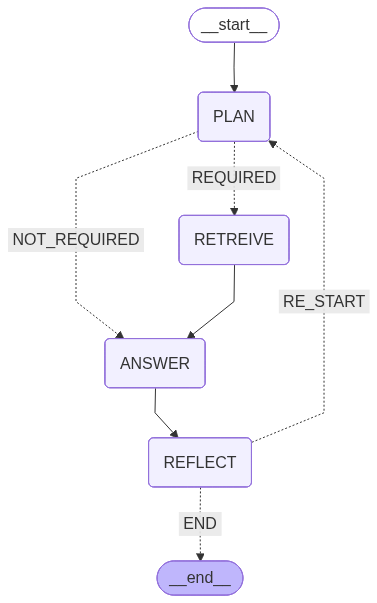

In [ ]:
graph

In [ ]:
graph.invoke({"query":"hii"})

{'decision': 'END',
 'query': 'hii',
 'answer': 'Hello! How can I help you today?'}

In [ ]:
def rag(input):
  for chunk in graph.stream(
      {"query":input}, stream_modes="updates"
      ):
    yield chunk

In [ ]:
rag("Summerize this paper")

{'PLAN': {'decision': 'REQUIRED'}}
{'RETREIVE': {'context': [['for text clustering. InProceedings of the 28th international conference on computational\nlinguistics, pages 5530–5534, 2020.', '• Retrieval-Augmented Generation (RAG).Retrieves relevant documents to enhance genera-\ntion.\nAssessment for SLM Replacement.SLMs would be well-suited for routine code generation', 'preparation [64, 62]. Application specific inputs (e.g. legal or internal documents) can\nbe often be automatically paraphrased to obfuscate named entities and numerical details', 'models [52].\n1The views and positions expressed in this paper are those of the authors and do not necessarily reflect the\nviews or positions of any entities they represent.\nPreprint. Under review.', '•Content Generation.Writes summaries, reports.\nAssessment for SLM ReplacementSLMs would be well-suited for tasks such as simple command', '[41] Akshi Kumar. From large to small: The rise of small language models (slms) in text analytics.\n2

## Demo Using Gradio

In [ ]:
import gradio as gr

def rag_to_talk(input):
  for chunk in graph.stream(
      {"query":input}, stream_modes="updates"
      ):

    if chunk.keys().__contains__("ANSWER"):
      yield chunk['ANSWER']['answer']

app = gr.Interface(
    rag_to_talk,
    inputs = gr.Textbox(lines=1, label="Input", placeholder="Ask something..."),
    outputs = gr.Textbox(lines=12, label="Answer", placeholder="Model response..."),
    title="RAG Chatbot"
)

app.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## Report


REPORT:
<br>
This Agent implements a Retreival-Augementated Genration (RAG) pipeline using langgraph framework. The Initial control of the agent goes to **plan node** which decides weather it would require any external context to answer the query of the user, if yes then the query is used to **retreive** pre-upserted external context (Here i used a PDF's content). after retreiving the top-k:10 chunks which are similar to the query, **answer node** is used to answer user's question based on the available context. However if at the very begining of the graph, **plan node** decides that no external context is required, the **answer node** generates the answer with any context. At last **reflect node** evaluate the correctness and relevancy of the generated answer with the respect to context, query and answer.

<br>

One key challenge i faced was during defining the graph, initially i wanted to avoid the need to using additional function for conditional_edges and use **plan node** and **reflect node** directly as conditioanl edges. though this resulted

<code>
error: *ValueError: At 'ANSWER' node, 'reflect' branch found unknown target '__start__'*
</code>

this error had resulted when i tried to condition if **REFLECT conditonal edge** outputs RE_START and then edge points to start, since **PLAN** was conditional edge rather than node which i could have pointed.

to avoid this error, i add **REFLECT** and **PLAN** as node while keeping them as conditional edges in usage. well this was sementically wrong and would throw runtime error. hence finally i removed these nodes as conditional edges and added additional function as conditional edges.

## Dataset: Created using LLM over the pdf: [Small Language Models are the Future of Agentic AI](https://arxiv.org/pdf/2506.02153)

In [ ]:
examples = [
    {
        "inputs": {"question": "What is the main position advocated by the paper 'Small Language Models are the Future of Agentic AI'?"},
        "outputs": {"answer": "The paper argues that small language models (SLMs) are sufficiently powerful, operationally suitable, and more economical than large language models (LLMs) for most agentic AI applications, making them the future of agentic systems."}
    },
    {
        "inputs": {"question": "How do the authors define a Small Language Model (SLM)?"},
        "outputs": {"answer": "An SLM is a language model that can fit on a consumer device and perform inference with low latency, practical for serving one user's agentic requests."}
    },
    {
        "inputs": {"question": "According to the authors, what are the three core views (V1–V3) supporting their position?"},
        "outputs": {"answer": "V1: SLMs are sufficiently powerful for agentic tasks; V2: SLMs are operationally more suitable; V3: SLMs are economically superior for most use cases."}
    },
    {
        "inputs": {"question": "What is meant by 'agentic system' in this paper?"},
        "outputs": {"answer": "An agentic system is an AI system that performs goal-directed actions such as planning, reasoning, tool use, and decision-making, typically powered by language models."}
    },
    {
        "inputs": {"question": "What examples do the authors provide of modern SLM families?"},
        "outputs": {"answer": "Examples include Microsoft Phi-2 and Phi-3, NVIDIA Nemotron-H, Hugging Face SmolLM2, NVIDIA Hymba-1.5B, DeepSeek-R1-Distill, DeepMind RETRO-7.5B, and Salesforce xLAM-2-8B."}
    },
    {
        "inputs": {"question": "Why are SLMs considered more economical for agentic systems?"},
        "outputs": {"answer": "They have lower inference cost, reduced latency, simpler infrastructure, and support inexpensive fine-tuning, making them cheaper to operate and deploy."}
    },
    {
        "inputs": {"question": "What is the main argument behind SLMs being sufficiently powerful?"},
        "outputs": {"answer": "Recent SLMs match or exceed older LLMs on reasoning, tool calling, and instruction-following tasks, showing that parameter count is no longer the main capability constraint."}
    },
    {
        "inputs": {"question": "What does the paper mean by 'heterogeneous agentic systems'?"},
        "outputs": {"answer": "Systems that combine multiple models of varying sizes—using SLMs for routine tasks and LLMs selectively for complex reasoning or open-domain dialogue."}
    },
    {
        "inputs": {"question": "How do SLMs contribute to the democratization of AI agents?"},
        "outputs": {"answer": "Their small size and low resource requirements enable wider participation in model training and deployment, promoting diversity and reducing systemic bias."}
    },
    {
        "inputs": {"question": "Why do the authors argue that LLM dominance in agent design is excessive?"},
        "outputs": {"answer": "Because most agentic subtasks are narrow, repetitive, and structured, which SLMs can handle efficiently without the high cost of LLMs."}
    },
    {
        "inputs": {"question": "What are some key efficiency metrics mentioned for SLMs?"},
        "outputs": {"answer": "A 7B SLM can be 10–30× cheaper in inference than a 70–175B LLM, and fine-tuning can take only a few GPU-hours using PEFT methods like LoRA or DoRA."}
    },
    {
        "inputs": {"question": "What is the 'LLM-to-SLM agent conversion algorithm' proposed by the authors?"},
        "outputs": {"answer": "It’s a six-step procedure: data collection, curation, task clustering, SLM selection, specialized fine-tuning, and iterative refinement to replace LLMs with SLMs in agents."}
    },
    {
        "inputs": {"question": "Why are SLMs seen as more flexible than LLMs?"},
        "outputs": {"answer": "Because their small size allows rapid fine-tuning, adaptation to local regulations, and deployment on edge devices, enabling quicker iteration and specialization."}
    },
    {
        "inputs": {"question": "What is the pragmatic argument for defining SLMs based on deployability?"},
        "outputs": {"answer": "Defining SLMs by their ability to run efficiently on consumer hardware ensures timelessness and practicality, avoiding dependence on hardware-specific parameter counts."}
    },
    {
        "inputs": {"question": "What does the paper list as the main barriers to SLM adoption?"},
        "outputs": {"answer": "B1: Heavy investment in centralized LLM infrastructure, B2: Benchmark bias favoring LLMs, and B3: Lack of awareness of SLM advantages."}
    },
    {
        "inputs": {"question": "How does the paper address the argument that LLMs have superior language understanding?"},
        "outputs": {"answer": "It rebuts that scaling law studies ignore architectural diversity and that small models can achieve comparable results through fine-tuning and test-time reasoning."}
    },
    {
        "inputs": {"question": "What does 'agentic interactions necessitate close behavioral alignment' mean?"},
        "outputs": {"answer": "Agentic workflows require strict adherence to data formats and APIs, so smaller fine-tuned models with consistent formatting are preferable to generalist LLMs."}
    },
    {
        "inputs": {"question": "What advantages do SLMs provide for edge deployment?"},
        "outputs": {"answer": "SLMs can run on consumer GPUs or local hardware with low latency, enabling offline and privacy-preserving inference through tools like NVIDIA ChatRTX."}
    },
    {
        "inputs": {"question": "What is meant by 'agentic interactions are natural data sources for model improvement'?"},
        "outputs": {"answer": "Each agent’s model/tool invocation produces structured logs that can be used to fine-tune specialized SLMs, continuously improving efficiency and accuracy."}
    },
    {
        "inputs": {"question": "What does the paper suggest about modularity in agentic systems?"},
        "outputs": {"answer": "Modular systems using multiple specialized SLMs are easier to debug, cheaper to scale, and better aligned with real-world heterogeneity of tasks."}
    },
    {
        "inputs": {"question": "How does the paper respond to the argument that centralized LLM inference is cheaper?"},
        "outputs": {"answer": "It notes that modern inference frameworks like NVIDIA Dynamo reduce infrastructure costs, making distributed SLM inference increasingly competitive."}
    },
    {
        "inputs": {"question": "What are 'equally possible worlds' discussed in Section 4.3?"},
        "outputs": {"answer": {"answer": "The authors consider that both SLM-first and LLM-first futures are possible, but they believe SLM advantages will eventually outweigh LLM inertia."}}
    },
    {
        "inputs": {"question": "In what percentage of cases can MetaGPT’s LLM calls be replaced by SLMs?"},
        "outputs": {"answer": "Approximately 60% of MetaGPT’s LLM queries could be reliably replaced by specialized SLMs."}
    },
    {
        "inputs": {"question": "According to the case study, what proportion of Open Operator’s queries can be replaced by SLMs?"},
        "outputs": {"answer": "About 40% of Open Operator’s LLM queries could be handled by specialized SLMs."}
    },
    {
        "inputs": {"question": "What about Cradle — how many LLM queries are replaceable with SLMs?"},
        "outputs": {"answer": "Roughly 70% of Cradle’s LLM queries could be managed by appropriately specialized SLMs."}
    },
    {
        "inputs": {"question": "What does the paper’s moral argument mean when it calls SLM adoption a 'Humean moral ought'?"},
        "outputs": {"answer": "The authors suggest that moving toward SLMs is not just technical optimization but an ethical responsibility for sustainability and resource efficiency."}
    },
    {
        "inputs": {"question": "Which tasks remain more suitable for LLMs according to the paper?"},
        "outputs": {"answer": "Tasks involving complex reasoning, open-ended dialogue, and broad world knowledge are still better suited for large models."}
    },
    {
        "inputs": {"question": "What is the role of task clustering in the LLM-to-SLM conversion algorithm?"},
        "outputs": {"answer": "Task clustering identifies recurring agentic operations from logged data, defining candidate tasks for specialized SLM fine-tuning."}
    },
    {
        "inputs": {"question": "How many training examples are typically sufficient to fine-tune an SLM specialist according to the paper?"},
        "outputs": {"answer": "Between 10,000 and 100,000 examples are generally sufficient for SLM fine-tuning."}
    },
    {
        "inputs": {"question": "What is the paper’s call to action in its conclusion?"},
        "outputs": {"answer": "The authors invite contributions and critiques to further the discussion on cost-efficient and sustainable AI, promoting SLM adoption in agentic AI."}
    }
]

## Evaluation


LLM-as-judge evaluators are often effective for evaluation in these cases because they can assess whether the agent got a job done directly from the text response. rather than non-llm metrics like ROUGE and BLUE, LLM-as-judge are able to evaluate output sementically

Most of Evaluation code is from: [Evaluate a RAG application](https://docs.langchain.com/langsmith/evaluate-rag-tutorial)

In [ ]:
from langsmith import Client

client = Client()

In [ ]:
# Check the Upper Dataset Section

dataset_name = "SM_QA_dataset"
dataset = client.create_dataset(dataset_name=dataset_name)
client.create_examples(
    dataset_id=dataset.id,
    examples=examples
)

{'example_ids': ['baab2707-5045-4af2-8891-641a3551ff22',
  'f5054701-b718-4642-81d3-dc5c41602585',
  'a69de74c-d769-42a0-a86c-b208a2605c6e',
  'a871c039-5509-4540-9e78-5a3d336820d3',
  '5f9e2000-6334-4c04-997e-6700ac064a2f',
  '3613f2a4-dd8a-41f9-9420-816ad816697c',
  'cf3fcd0f-472d-42ad-9b39-7495fa1bc896',
  '6fae57ec-9b13-43e1-bf17-6939e1a33a45',
  '597c5bbd-0ace-4791-83e3-a97c6bd2b413',
  '8e074e4a-d973-498f-939b-562bcc84125c',
  'dfe1b550-3551-4dfa-bbaa-9d7dc43387aa',
  'f674dcd8-cf67-4b8a-b80e-a9554f9624c5',
  'b4296507-c5cd-4b15-9f38-2398c1a9d16d',
  'd6697cb4-7d5e-4dbe-8bf6-88726c8e1a4e',
  'c3fe7cd9-7e1a-4c8b-8276-efd70db3742f',
  'cee1dbd0-5f7e-45c7-94d1-c25500148692',
  '37f283c0-95f5-4d9a-82b8-80381e9c2d4c',
  '1f72de0d-2850-4359-acea-2571ae019570',
  'e43398c3-77d5-4c84-8ae1-e1289a376bca',
  '10de72e5-2a40-4de9-b030-e321a10c9210',
  'e0b8aa1c-1acb-40a5-b361-c6f377378402',
  '02b420d1-9973-478b-9ccf-f09e3722851e',
  'f7ece7fd-07a0-4f28-95f4-fca8cd56f122',
  '12cdf239-a0f3-4d

**Evaluator for: Correctness: Response vs reference answer**

In [ ]:
from typing_extensions import Annotated, TypedDict

# Grade output schema
class CorrectnessGrade(TypedDict):
    # Note that the order in the fields are defined is the order in which the model will generate them.
    # It is useful to put explanations before responses because it forces the model to think through
    # its final response before generating it:
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    correct: Annotated[bool, ..., "True if the answer is correct, False otherwise."]

# Grade prompt
correctness_instructions = """You are a teacher grading a quiz. You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER. Here is the grade criteria to follow:
(1) Grade the student answers based ONLY on their factual accuracy relative to the ground truth answer. (2) Ensure that the student answer does not contain any conflicting statements.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is factually accurate relative to the  ground truth answer.

Correctness:
A correctness value of True means that the student's answer meets all of the criteria.
A correctness value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. Avoid simply stating the correct answer at the outset."""

# Grader LLM
grader_llm = llm.with_structured_output(
    CorrectnessGrade, method="json_schema", strict=True
)

def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """An evaluator for RAG answer accuracy"""
    answers = f"""\
QUESTION: {inputs['question']}
GROUND TRUTH ANSWER: {reference_outputs['answer']}
STUDENT ANSWER: {outputs['answer']}"""
    # Run evaluator
    grade = grader_llm.invoke([
        {"role": "system", "content": correctness_instructions},
        {"role": "user", "content": answers}
    ])
    return grade["correct"]

**Evaluator for: Relevance: Response vs input**

In [ ]:
# Grade output schema
class RelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[
        bool, ..., "Provide the score on whether the answer addresses the question"
    ]

# Grade prompt
relevance_instructions = """You are a teacher grading a quiz. You will be given a QUESTION and a STUDENT ANSWER. Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is concise and relevant to the QUESTION
(2) Ensure the STUDENT ANSWER helps to answer the QUESTION

Relevance:
A relevance value of True means that the student's answer meets all of the criteria.
A relevance value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. Avoid simply stating the correct answer at the outset."""

# Grader LLM
relevance_llm = llm.with_structured_output(
    RelevanceGrade, method="json_schema", strict=True
)

# Evaluator
def relevance(inputs: dict, outputs: dict) -> bool:
    """A simple evaluator for RAG answer helpfulness."""
    answer = f"QUESTION: {inputs['question']}\nSTUDENT ANSWER: {outputs['answer']}"
    grade = relevance_llm.invoke([
        {"role": "system", "content": relevance_instructions},
        {"role": "user", "content": answer}
    ])
    return grade["relevant"]

**Evaluator for: Groundedness: Response vs retrieved docs**

In [ ]:
# Grade output schema
class GroundedGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    grounded: Annotated[
        bool, ..., "Provide the score on if the answer hallucinates from the documents"
    ]

# Grade prompt
grounded_instructions = """You are a teacher grading a quiz. You will be given FACTS and a STUDENT ANSWER. Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is grounded in the FACTS. (2) Ensure the STUDENT ANSWER does not contain "hallucinated" information outside the scope of the FACTS.

Grounded:
A grounded value of True means that the student's answer meets all of the criteria.
A grounded value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. Avoid simply stating the correct answer at the outset."""

# Grader LLM
grounded_llm = llm.with_structured_output(
    GroundedGrade, method="json_schema", strict=True
)

# Evaluator
def groundedness(inputs: dict, outputs: dict) -> bool:
    """A simple evaluator for RAG answer groundedness."""
    doc_string = "\n\n".join(
        "\n".join(doc) if isinstance(doc, list) else str(doc)
        for doc in outputs["context"]
    )
    answer = f"FACTS: {doc_string}\nSTUDENT ANSWER: {outputs['answer']}"
    grade = grounded_llm.invoke([
        {"role": "system", "content": grounded_instructions},
        {"role": "user", "content": answer}
    ])
    return grade["grounded"]

**Evaluator for: Retrieval relevance: Retrieved docs vs input**

In [ ]:
# Grade output schema
class RetrievalRelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[
        bool,
        ...,
        "True if the retrieved documents are relevant to the question, False otherwise",
    ]

# Grade prompt
retrieval_relevance_instructions = """You are a teacher grading a quiz. You will be given a QUESTION and a set of FACTS provided by the student. Here is the grade criteria to follow:
(1) You goal is to identify FACTS that are completely unrelated to the QUESTION
(2) If the facts contain ANY keywords or semantic meaning related to the question, consider them relevant
(3) It is OK if the facts have SOME information that is unrelated to the question as long as (2) is met

Relevance:
A relevance value of True means that the FACTS contain ANY keywords or semantic meaning related to the QUESTION and are therefore relevant.
A relevance value of False means that the FACTS are completely unrelated to the QUESTION.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. Avoid simply stating the correct answer at the outset."""

# Grader LLM
retrieval_relevance_llm = llm.with_structured_output(RetrievalRelevanceGrade, method="json_schema", strict=True)

def retrieval_relevance(inputs: dict, outputs: dict) -> bool:
    """An evaluator for document relevance"""
    doc_string = "\n\n".join(
        "\n".join(doc) if isinstance(doc, list) else str(doc)
        for doc in outputs["context"]
    )
    answer = f"FACTS: {doc_string}\nQUESTION: {inputs['question']}"
    # Run evaluator
    grade = retrieval_relevance_llm.invoke([
        {"role": "system", "content": retrieval_relevance_instructions},
        {"role": "user", "content": answer}
    ])
    return grade["relevant"]

In [ ]:
def target(inputs: dict) -> dict:
    return graph.invoke({"query": inputs["question"]})

experiment_results = client.evaluate(
    target,
    data=dataset_name,
    evaluators=[correctness, groundedness, relevance, retrieval_relevance],
    experiment_prefix="rag_evaluation",
    metadata={"file": "rag"},
)

# Explore results locally as a dataframe if you have pandas installed
experiment_results.to_pandas()

View the evaluation results for experiment: 'rag_evaluation-fee40206' at:
https://smith.langchain.com/o/526402cb-12a3-41ce-b78b-de4164f99372/datasets/5c155c9e-5b96-4fb3-b8b2-5c65f2904f6f/compare?selectedSessions=f9855d55-68e3-487e-b80f-6a0494619ea8




0it [00:00, ?it/s]

ERROR:langsmith.evaluation._runner:Error running evaluator <DynamicRunEvaluator groundedness> on run 73a079b4-e0eb-464e-bd0d-de4af827a9ba: KeyError('context')
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/langsmith/evaluation/_runner.py", line 1619, in _run_evaluators
    evaluator_response = evaluator.evaluate_run(  # type: ignore[call-arg]
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/langsmith/evaluation/evaluator.py", line 351, in evaluate_run
    result = self.func(
             ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/langsmith/evaluation/evaluator.py", line 777, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-3344668724.py", line 28, in groundedness
    for doc in outputs["context"]
               ~~~~~~~^^^^^^^^^^^
KeyError: 'context'
ERROR:langsmith.evaluation._runner:Error running evaluator 

,inputs.question,outputs.decision,outputs.query,outputs.context,outputs.answer,error,reference.answer,feedback.correctness,feedback.groundedness,feedback.relevance,feedback.retrieval_relevance,execution_time,example_id,id,feedback.wrapper,outputs.output
0,What is the paper’s call to action in its conc...,END,What is the paper’s call to action in its conc...,[[explore all options for doing so.\nWe theref...,In the final section the authors explicitly in...,None,The authors invite contributions and critiques...,True,False,True,True,1.209579,01b6c015-b588-4b72-b294-53c38229ab01,6ee27e8d-59d1-4503-a8b9-c6e8f1f46e01,NaN,NaN
1,What is meant by 'agentic system' in this paper?,END,What is meant by 'agentic system' in this paper?,[[We use the wordsagentandagentic systeminterc...,"In the paper, an **agentic system** is simply ...",None,An agentic system is an AI system that perform...,True,False,True,True,13.376476,02b420d1-9973-478b-9ccf-f09e3722851e,03c834f5-9f34-49e5-a4b2-3ff6cc9af7c4,NaN,NaN
2,Which tasks remain more suitable for LLMs acco...,END,Which tasks remain more suitable for LLMs acco...,[[reasoning or the ability to maintain convers...,"According to the paper, the tasks that still f...",None,"Tasks involving complex reasoning, open-ended ...",True,True,True,True,14.188757,0ee39619-fb5a-4b15-bb65-608f9eee2fdd,a7eec838-4cec-4bdd-8ce1-f5dab31e80c1,NaN,NaN
3,What is meant by 'agentic interactions are nat...,END,What is meant by 'agentic interactions are nat...,NaN,**Agentic interactions** are the kinds of conv...,None,Each agent’s model/tool invocation produces st...,True,NaN,True,NaN,8.124078,10de72e5-2a40-4de9-b030-e321a10c9210,73a079b4-e0eb-464e-bd0d-de4af827a9ba,NaN,NaN
4,What does the paper suggest about modularity i...,END,What does the paper suggest about modularity i...,[[sense for modularity in the context of agent...,The paper argues that **modularity is essentia...,None,Modular systems using multiple specialized SLM...,NaN,True,True,True,14.252858,12cdf239-a0f3-4db0-a56f-9f9c3c521471,79d6c3e1-26e6-4703-9971-b7a9f10f33bb,NaN,NaN
5,What is the role of task clustering in the LLM...,END,What is the role of task clustering in the LLM...,[[and agent actions to identify recurring patt...,Task clustering is used to **identify and grou...,None,Task clustering identifies recurring agentic o...,True,True,True,True,13.605548,1f72de0d-2850-4359-acea-2571ae019570,793db7b3-bd6a-46fb-9451-58d159b6a8bd,NaN,NaN
6,What does the paper’s moral argument mean when...,END,What does the paper’s moral argument mean when...,[[The phrasing of our position is deliberate. ...,"In the paper, describing SLM adoption as a **“...",None,The authors suggest that moving toward SLMs is...,True,True,True,True,14.866332,3613f2a4-dd8a-41f9-9420-816ad816697c,6f7f4744-2110-4e59-a59c-4eba777f09a5,NaN,NaN
7,What is the pragmatic argument for defining SL...,END,What is the pragmatic argument for defining SL...,[[• Practicality.The definition is likely to h...,The pragmatic argument is that a definition of...,None,Defining SLMs by their ability to run efficien...,True,True,True,True,14.159463,37f283c0-95f5-4d9a-82b8-80381e9c2d4c,305e4ab6-f557-4dae-b48b-ffd32741e726,NaN,NaN
8,How does the paper address the argument that L...,END,How does the paper address the argument that L...,[[A conclusion can be then drawn that LLM gene...,The paper acknowledges that a growing body of ...,None,It rebuts that scaling law studies ignore arch...,False,True,True,True,14.739612,597c5bbd-0ace-4791-83e3-a97c6bd2b413,3cc2f81b-3832-4c45-9e19-5af99a322553,NaN,NaN
9,What about Cradle — how many LLM queries are r...,END,What about Cradle — how many LLM queries are r...,[[which would require a higher degree of conte...,"In the case of **Cradle**, the analysis estima...",None,Roughly 70% of Cradle’s LLM queries could be m...,True,True,True,True,13.320714,5f9e2000-6334-4c04-997e-6700ac064a2f,b91215a9-36cd-49a6-95ab-d7390f72216f,NaN,NaN
